In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, chi2
from scipy.linalg import expm
from scipy.stats import kstest

seed = 42

<h1>Task 7</h1>

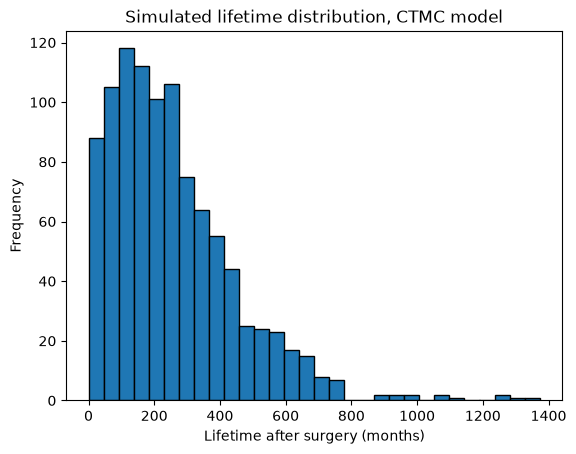

Mean lifetime: 256.37 months
95% CI for mean: (244.31, 268.43)
Standard deviation: 194.38 months
95% CI for standard deviation: (186.22, 203.29)
Proportion with distant recurrence by 30.5 months: 0.084


In [4]:
Q = np.array([
    [-0.0085, 0.005,  0.0025, 0,     0.001],
    [0,      -0.014,  0.005,  0.004, 0.005],
    [0,       0,     -0.008,  0.003, 0.005],
    [0,       0,      0,     -0.009, 0.009],
    [0,       0,      0,      0,     0]
])

def simulate_one(Q, start_state=0, death_state=4):
    state = start_state
    time = 0.0

    trajectory = [state]
    jump_times = [time]

    while state != death_state:
        rate = -Q[state, state]

        # Time spent in current state
        wait_time = np.random.exponential(scale=1 / rate)
        time += wait_time

        # Probabilities of jumping to each other state
        probs = Q[state].copy()
        probs[state] = 0
        probs = probs / rate

        # Choose next state
        state = np.random.choice(len(Q), p=probs)

        trajectory.append(state)
        jump_times.append(time)

    return time, trajectory, jump_times

def simulate_many(Q, n=1000, seed=None):
    if seed is not None:
        np.random.seed(seed)

    lifetimes = []
    trajectories = []
    jump_times_all = []

    for _ in range(n):
        lifetime, trajectory, jump_times = simulate_one(Q)
        lifetimes.append(lifetime)
        trajectories.append(trajectory)
        jump_times_all.append(jump_times)

    return np.array(lifetimes), trajectories, jump_times_all


lifetimes, trajectories, jump_times_all = simulate_many(Q, n=1000, seed=seed)

plt.hist(lifetimes, bins=30, edgecolor="black")
plt.xlabel("Lifetime after surgery (months)")
plt.ylabel("Frequency")
plt.title("Simulated lifetime distribution, CTMC model")
plt.show()

# Calculate mean, standard deviation, and confidence intervals
n = len(lifetimes)
alpha = 0.05

mean_lifetime = np.mean(lifetimes)
sd_lifetime = np.std(lifetimes, ddof=1)

# 95% CI for the mean
se_mean = sd_lifetime / np.sqrt(n)
t_crit = t.ppf(1 - alpha / 2, df=n - 1)

mean_ci = (
    mean_lifetime - t_crit * se_mean,
    mean_lifetime + t_crit * se_mean
)

# 95% CI for the standard deviation
chi2_lower = chi2.ppf(alpha / 2, df=n - 1)
chi2_upper = chi2.ppf(1 - alpha / 2, df=n - 1)

var_ci = (
    (n - 1) * sd_lifetime**2 / chi2_upper,
    (n - 1) * sd_lifetime**2 / chi2_lower
)

sd_ci = (
    np.sqrt(var_ci[0]),
    np.sqrt(var_ci[1])
)

print(f"Mean lifetime: {mean_lifetime:.2f} months")
print(f"95% CI for mean: ({mean_ci[0]:.2f}, {mean_ci[1]:.2f})")

print(f"Standard deviation: {sd_lifetime:.2f} months")
print(f"95% CI for standard deviation: ({sd_ci[0]:.2f}, {sd_ci[1]:.2f})")

# Calculate the amount of patients where cancer reappears after 30.5 months
def has_distant_recurrence_by_time(trajectory, jump_times, t=30.5):
    """
    Returns True if the woman has entered state 3 or 4 by time t.
    
    Python states:
        0 = state 1
        1 = state 2, local recurrence
        2 = state 3, distant recurrence
        3 = state 4, local + distant recurrence
        4 = state 5, death
    """
    for state, jump_time in zip(trajectory, jump_times):
        if jump_time <= t and state in [2, 3]:
            return True
    return False


distant_by_30_5 = [
    has_distant_recurrence_by_time(traj, times, t=30.5)
    for traj, times in zip(trajectories, jump_times_all)
]

prop_distant = np.mean(distant_by_30_5)

print(f"Proportion with distant recurrence by 30.5 months: {prop_distant:.3f}")

<h1>Task 8</h1>

KS statistic: 0.0239
p-value: 0.6110


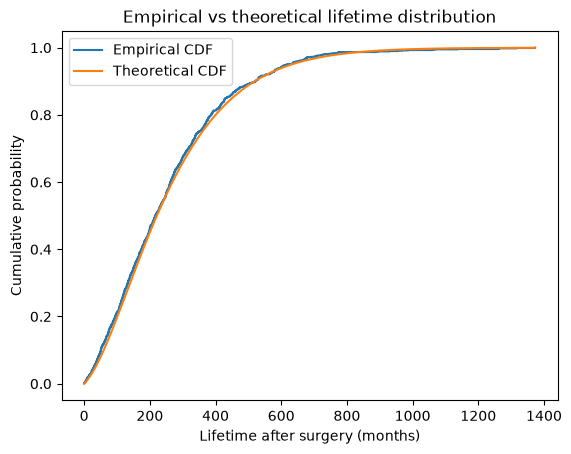

In [7]:
Qs = Q[:4, :4]
p0 = np.array([1, 0, 0, 0])
ones = np.ones(4)

def theoretical_cdf(t):
    return 1 - p0 @ expm(Qs * t) @ ones

# Helper for KS test
def theoretical_cdf_vectorized(x):
    x = np.asarray(x)
    return np.array([theoretical_cdf(t) for t in x])

ks_statistic, p_value = kstest(lifetimes, theoretical_cdf_vectorized)

print(f"KS statistic: {ks_statistic:.4f}")
print(f"p-value: {p_value:.4f}")

# Empirical CDF
sorted_lifetimes = np.sort(lifetimes)
empirical_cdf = np.arange(1, len(sorted_lifetimes) + 1) / len(sorted_lifetimes)

# Theoretical CDF
t_values = np.linspace(0, max(lifetimes), 500)
theoretical_values = theoretical_cdf_vectorized(t_values)

plt.step(sorted_lifetimes, empirical_cdf, where="post", label="Empirical CDF")
plt.plot(t_values, theoretical_values, label="Theoretical CDF")
plt.xlabel("Lifetime after surgery (months)")
plt.ylabel("Cumulative probability")
plt.title("Empirical vs theoretical lifetime distribution")
plt.legend()
plt.show()

<h1>Task 9</h1>

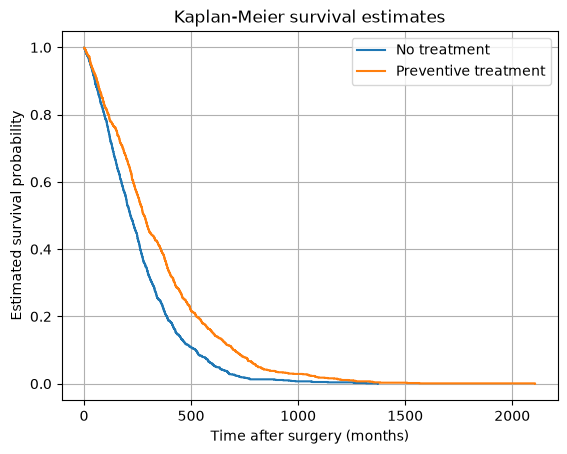

In [8]:
Q_treatment = np.array([
    [0, 0.0025, 0.00125, 0,     0.001],
    [0, 0,      0,       0.002, 0.005],
    [0, 0,      0,       0.003, 0.005],
    [0, 0,      0,       0,     0.009],
    [0, 0,      0,       0,     0]
])

for i in range(Q_treatment.shape[0]):
    Q_treatment[i, i] = -np.sum(Q_treatment[i, :])

lifetimes_treatment, trajectories_treatment, jump_times_treatment = simulate_many(
    Q_treatment, 
    n=1000, 
    seed=seed
)

def kaplan_meier_curve(lifetimes):
    lifetimes_sorted = np.sort(lifetimes)
    n = len(lifetimes_sorted)

    times = lifetimes_sorted
    survival_probs = 1 - np.arange(1, n + 1) / n

    return times, survival_probs

times_no, survival_no = kaplan_meier_curve(lifetimes)
times_treat, survival_treat = kaplan_meier_curve(lifetimes_treatment)

plt.step(times_no, survival_no, where="post", label="No treatment")
plt.step(times_treat, survival_treat, where="post", label="Preventive treatment")

plt.xlabel("Time after surgery (months)")
plt.ylabel("Estimated survival probability")
plt.title("Kaplan-Meier survival estimates")
plt.legend()
plt.grid(True)
plt.show()